**Analysis of the pypsa .nc files**

Here we explore and plot electricity prices in different scenarios

INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores




Imported network with components: ['buses', 'carriers', 'generators', 'loads', 'links', 'stores', 'storage_units', 'lines', 'line_types', 'transformers', 'transformer_types', 'shunt_impedances', 'global_constraints', 'shapes', 'sub_networks']
n_buses: 879
n_buses columns: ['v_nom', 'type', 'x', 'y', 'carrier', 'unit', 'location', 'v_mag_pu_set', 'v_mag_pu_min', 'v_mag_pu_max', 'control', 'generator', 'sub_network', 'country']
Unique bus carriers (sample): <StringArray>
[                           'AC',                       'lignite',
                          'coal',                           'oil',
                       'uranium',                          'none',
                           'co2',                    'co2 stored',
               'co2 sequestered',                           'gas',
                            'H2',                       'battery',
                        'Li ion',        'residential rural heat',
 'residential rural water tanks']
Length: 15, dtype: st

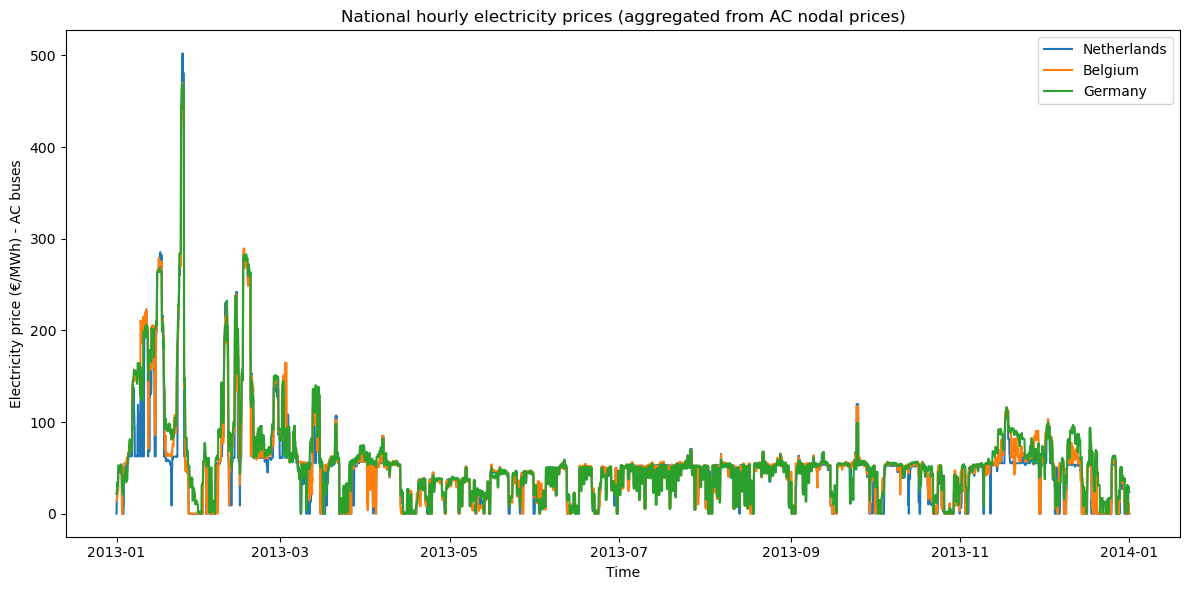


--- Spike diagnostic for BE ---
Spike at: 2013-01-24 18:00:00 value: 469.92535383609555

Top nodal prices at spike:
name
BE1 0    469.925354
Name: 2013-01-24 18:00:00, dtype: float64

AC line loadings (effective):
          flow_MW    s_nom_eff  s_max_pu      cap_eff  loading_eff
name                                                              
17    3349.050157  6792.410569       0.5  3396.205285     0.986115
14    3349.051465  6792.413509       0.5  3396.206755     0.986115
16     355.374150  1042.293839       0.5   521.146919     0.681908
15     887.721057  2951.585975       0.5  1475.792987     0.601521

Top link loadings:
                                               flow_MW     p_nom_eff  \
name                                                                   
BE1 0 urban central gas CHP CC                0.184457      0.176312   
BE1 0 H2 Fuel Cell                            0.105953      0.101540   
BE1 0 urban central gas CHP                   0.674223      0.669858   
BE1

In [ ]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt

####### 0) INPUT
# retro_tes - 2030
# path_nc = r'data/electricity_data/retro-tes_2030.nc'
# retro_tes - 2040
# path_nc = r'data/electricity_data/retro-tes_2040.nc'
# retro_tes - 2050
# path_nc = r'data/electricity_data/retro-tes_2050.nc'
# flexible - 2030
#path_nc = r'data/electricity_data/flexible_2030.nc'
# flexible - 2040
# path_nc = r'data/electricity_data/flexible_2040.nc'
# flexible - 2050
path_nc = r'data/electricity_data/flexible_2050.nc'
# flexible_moderate - 2030
# path_nc = r'data/electricity_data/flexible-moderate_2030.nc'
# flexible_moderate - 2040
# path_nc = r'data/electricity_data/flexible-moderate_2040.nc'
# flexible_moderate - 2050
# path_nc = r'data/electricity_data/flexible-moderate_2050.nc'
# rigid - 2030
# path_nc = r'data/electricity_data/rigid_2030.nc'
# rigid - 2040
# path_nc = r'data/electricity_data/rigid_2040.nc'
# rigid - 2050
# path_nc = r'data/electricity_data/rigid_2050.nc'

COUNTRIES = ["NL", "BE", "DE"]

####### 1) LOAD NETWORK
n = pypsa.Network(path_nc)

print(f"\n\nImported network with components:", [c for c in n.components.keys() if getattr(n, c.lower(), None) is not None])
print("n_buses:", len(n.buses))
print("n_buses columns:", n.buses.columns.tolist())
print("Unique bus carriers (sample):", n.buses["carrier"].unique()[:15] if "carrier" in n.buses.columns else "no carrier col")
print("Unique countries (sample):", sorted(n.buses["country"].dropna().unique())[:15] if "country" in n.buses.columns else "no country col")

####### 2) FILTER ELECTRIC AC BUSES + COUNTRIES
# (A) Bus AC = "wholesale electricity". We exclude buses with empty country.
ac_buses = n.buses.index[(n.buses["carrier"] == "AC") & (n.buses["country"] != "")]

# (B) Keep only NL/BE/DE
ac_buses_c = ac_buses[n.buses.loc[ac_buses, "country"].isin(COUNTRIES)]

print("\nAC buses total:", len(ac_buses))
print("AC buses in NL/BE/DE:", len(ac_buses_c))
print("AC buses count by country:\n", n.buses.loc[ac_buses_c, "country"].value_counts())

####### 3) HOURLY NODAL PRICES (ONLY ON FILTERED AC BUSES)
# Nodal prices (shadow price of nodal balance) in €/MWh
p_ac = n.buses_t.marginal_price[ac_buses_c].copy()

# map bus->country
bus_country = n.buses.loc[ac_buses_c, "country"]

####### 4) BUILD "NATIONAL" PRICE
# Path 1: simple average over AC buses of the country
p_country_mean = p_ac.T.groupby(bus_country).mean().T

# Path 2: median
p_country_median = p_ac.T.groupby(bus_country).median().T

# Path 3: load-weighted average
# - We build load per bus: sum all loads connected to the same bus.
# - We keep only the filtered AC buses.
# WARNING: if in this network the electric loads are on "low voltage" buses, here you will have many zeros in the denominator.
load_bus = n.loads_t.p_set.T.groupby(n.loads.bus).sum().T
load_bus_ac = load_bus.reindex(columns=ac_buses_c).fillna(0.0)

num = (p_ac * load_bus_ac).T.groupby(bus_country).sum().T
den = load_bus_ac.T.groupby(bus_country).sum().T

# Avoid division by zero: where den==0 set NaN
p_country_weighted = (num / den).replace([pd.NA, float("inf"), -float("inf")], pd.NA)

print("\nCheck denominators (how many hours with den==0):")
for c in COUNTRIES:
    if c in den.columns:
        print(c, (den[c] == 0).sum())
    else:
        print(c, "not present in den columns")

# Choose which price to use for the plot (recommendation: mean or weighted if denominators are okay)
# If weighted has many NaN/den==0, use mean.
use_weighted = True
p_country = p_country_weighted if use_weighted else p_country_mean

# If weighted produces many NaN, automatic fallback to mean
for c in COUNTRIES:
    if c in p_country.columns and p_country[c].isna().mean() > 0.05:  # >5% NaN
        print(f"\nWARNING: {c} weighted has many NaN -> fallback to mean for that country.")
        p_country[c] = p_country_mean[c]

# Check how many hours with extreme prices
print("\nExtreme price counts (>300 €/MWh and >500 €/MWh):")
for c in COUNTRIES:
    s = p_country[c]
    print(c, " >300:", (s>300).sum(), " >500:", (s>500).sum(), "max:", s.max())

# extract series
p_NL = p_country["NL"] if "NL" in p_country.columns else None
p_BE = p_country["BE"] if "BE" in p_country.columns else None
p_DE = p_country["DE"] if "DE" in p_country.columns else None

####### 5) PLOT NATIONAL PRICES
plt.figure(figsize=(12, 6))
if p_NL is not None:
    plt.plot(p_NL.index, p_NL.values, label="Netherlands")
if p_BE is not None:
    plt.plot(p_BE.index, p_BE.values, label="Belgium")
if p_DE is not None:
    plt.plot(p_DE.index, p_DE.values, label="Germany")

plt.xlabel("Time")
plt.ylabel("Electricity price (€/MWh) - AC buses")
plt.title("National hourly electricity prices (aggregated from AC nodal prices)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 6) SPIKE DIAGNOSIS
# -----------------------------
# If you see strange spikes, check:
# A) which hour and which bus/country generates it
# B) congestion on lines/links connected to the country's bus
# Note: NL and BE often have only 1 bus (s_48), so the spike is exactly that bus.

def diagnose_spike(country_code: str):
    if country_code not in p_country.columns:
        print(f"{country_code} not in p_country.")
        return

    t_spike = p_country[country_code].idxmax()
    val = p_country[country_code].loc[t_spike]
    print(f"\n--- Spike diagnostic for {country_code} ---")
    print("Spike at:", t_spike, "value:", val)

    # buses AC in that country
    buses_c = ac_buses_c[n.buses.loc[ac_buses_c, "country"] == country_code]

    # nodal prices of those buses at that hour
    p_nodes = n.buses_t.marginal_price[buses_c].loc[t_spike].sort_values(ascending=False)
    print("\nTop nodal prices at spike:")
    print(p_nodes.head(10))

    # if country has 1 bus, take that one
    main_bus = p_nodes.index[0]

    # (1) line congestion: use effective capacity = s_nom_eff * s_max_pu
    lines = n.lines.index[(n.lines.bus0 == main_bus) | (n.lines.bus1 == main_bus)]
    if len(lines):
        flow = n.lines_t.p0.loc[t_spike, lines].abs()
        s_nom_eff = n.lines.loc[lines, "s_nom_opt"].fillna(n.lines.loc[lines, "s_nom"])
        s_max_pu = n.lines.loc[lines, "s_max_pu"].fillna(1.0)
        cap_eff = s_nom_eff * s_max_pu
        loading_eff = (flow / cap_eff).sort_values(ascending=False)

        out = pd.DataFrame({
            "flow_MW": flow,
            "s_nom_eff": s_nom_eff,
            "s_max_pu": s_max_pu,
            "cap_eff": cap_eff,
            "loading_eff": loading_eff
        }).sort_values("loading_eff", ascending=False)

        print("\nAC line loadings (effective):")
        print(out.head(10))
    else:
        print("\nNo AC lines connected to", main_bus)

    # (2) link congestion: use p_nom_eff (opt if present)
    links = n.links.index[(n.links.bus0 == main_bus) | (n.links.bus1 == main_bus)]
    if len(links):
        # effective capacity p_nom_eff (opt if present)
        p_nom_eff = n.links.loc[links, "p_nom_opt"].fillna(n.links.loc[links, "p_nom"])
        flow = n.links_t.p0.loc[t_spike, links].abs()
        loading = (flow / p_nom_eff).sort_values(ascending=False)

        outL = pd.DataFrame({
            "flow_MW": flow,
            "p_nom_eff": p_nom_eff,
            "loading": loading,
            "carrier": n.links.loc[links, "carrier"].astype(str)
        }).sort_values("loading", ascending=False)

        print("\nTop link loadings:")
        print(outL.head(15))

        # details of suspicious links (loading>0.99)
        suspicious = outL[outL["loading"] > 0.99].head(10).index
        if len(suspicious):
            cols = [c for c in ["carrier","bus0","bus1","efficiency","marginal_cost","capital_cost"] if c in n.links.columns]
            print("\nSuspicious links details (loading>0.99):")
            print(n.links.loc[suspicious, cols])
    else:
        print("\nNo links connected to", main_bus)

# Example: diagnose spike BE (as in your case)
diagnose_spike("BE")
diagnose_spike("NL")
diagnose_spike("DE")


**Non-recoverable fees**

We fetch data from Eurostat database, considering "Excluding taxes and levies" and "Excluding VAT and other recoverable taxes and levies" values, and we subtract the two values to find the non-recoverable taxes

In [2]:
import requests
import pandas as pd
from urllib.parse import quote

def fetch_dbnomics_series(provider: str, dataset: str, series_code: str) -> pd.Series:
    """
    Fetch Eurostat nrg_pc_205 series through DBnomics Web API.
    Returns a pandas Series indexed by period_start_day (datetime), values in €/kWh.
    """
    base = f"https://api.db.nomics.world/v22/series/{provider}/{dataset}/{quote(series_code, safe='.')}"
    params = {"observations": 1, "metadata": 0}

    r = requests.get(base, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()

    doc = js["series"]["docs"][0]

    # Se manca, significa che non sono arrivate le osservazioni
    if "period_start_day" not in doc or "value" not in doc:
        raise RuntimeError(
            f"Nessuna osservazione nella risposta. "
            f"Controlla observations=1. Keys disponibili: {list(doc.keys())}"
        )

    idx = pd.to_datetime(doc["period_start_day"])
    s = pd.Series(doc["value"], index=idx, name=series_code).sort_index()

    return s

countries = ["NL", "BE", "DE"]

no_tax_code = 'X_TAX'
no_vat_code = 'X_VAT'

fee_df = pd.DataFrame(columns=countries)

for country in countries:
    no_tax_series_code = f"S.6000.MWH_GE150000.KWH.{no_tax_code}.EUR.{country}"
    no_vat_series_code = f"S.6000.MWH_GE150000.KWH.{no_vat_code}.EUR.{country}"
    no_tax = fetch_dbnomics_series("Eurostat", "nrg_pc_205", no_tax_series_code)
    no_vat = fetch_dbnomics_series("Eurostat", "nrg_pc_205", no_vat_series_code)

    fee_df[country] = (no_vat - no_tax) * 1000  # convert to €/MWh


print(fee_df.tail())

             NL   BE    DE
2023-01-01  3.5  2.9  14.9
2023-07-01  1.9  2.6  14.8
2024-01-01  3.6  3.6   6.7
2024-07-01  1.9  3.2   6.7
2025-01-01  4.3  6.8  13.3


**Save results to csv**

Here we save the price array just analysed as a CSV

In [ ]:
import os
import re
import pypsa
import pandas as pd
import requests
from urllib.parse import quote

COUNTRIES = ["NL", "BE", "DE"]

def fetch_dbnomics_series(provider: str, dataset: str, series_code: str) -> pd.Series:
    """
    Fetch Eurostat nrg_pc_205 series through DBnomics Web API.
    Returns a pandas Series indexed by period_start_day (datetime), values in €/kWh.
    """
    base = f"https://api.db.nomics.world/v22/series/{provider}/{dataset}/{quote(series_code, safe='.')}"
    params = {"observations": 1, "metadata": 0}

    r = requests.get(base, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()

    doc = js["series"]["docs"][0]

    # if missing, means no observations returned
    if "period_start_day" not in doc or "value" not in doc:
        raise RuntimeError(
            f"No observations in response. "
            f"Check observations=1. Available keys: {list(doc.keys())}"
        )

    idx = pd.to_datetime(doc["period_start_day"])
    s = pd.Series(doc["value"], index=idx, name=series_code).sort_index()

    return s

def get_fee_dataframe(countries=COUNTRIES) -> pd.DataFrame:
    """
    Fetch fee DataFrame from Eurostat via DBnomics.
    Returns DataFrame with datetime index and country columns (€/MWh).
    """
    no_tax_code = 'X_TAX'
    no_vat_code = 'X_VAT'

    fee_df = pd.DataFrame(columns=countries)

    for country in countries:
        no_tax_series_code = f"S.6000.MWH_GE150000.KWH.{no_tax_code}.EUR.{country}"
        no_vat_series_code = f"S.6000.MWH_GE150000.KWH.{no_vat_code}.EUR.{country}"
        no_tax = fetch_dbnomics_series("Eurostat", "nrg_pc_205", no_tax_series_code)
        no_vat = fetch_dbnomics_series("Eurostat", "nrg_pc_205", no_vat_series_code)

        fee_df[country] = (no_vat - no_tax) * 1000  # convert to €/MWh

    return fee_df

def extract_ac_country_prices(n: pypsa.Network, countries=COUNTRIES, agg="mean") -> pd.DataFrame:
    """
    Extract electric prices (carrier='AC') and aggregate by country.
    agg: 'mean' or 'median'
    Returns DataFrame with datetime index and country columns.
    """
    # 1) filter AC buses with non-empty country
    ac_buses = n.buses.index[(n.buses["carrier"] == "AC") & (n.buses["country"] != "")]
    ac_buses = ac_buses[n.buses.loc[ac_buses, "country"].isin(countries)]

    if len(ac_buses) == 0:
        raise ValueError("No AC buses found for the requested countries. Check carrier/country in the network.")

    # 2) nodal prices on filtered AC buses
    p_ac = n.buses_t.marginal_price[ac_buses].copy()
    bus_country = n.buses.loc[ac_buses, "country"]

    # 3) aggregation by country (avoid deprecated axis=1)
    if agg == "mean":
        p_country = p_ac.T.groupby(bus_country).mean().T
    elif agg == "median":
        p_country = p_ac.T.groupby(bus_country).median().T
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    # 4) keep only requested columns and in order
    p_country = p_country.reindex(columns=countries)

    # (optional) ensure index is datetime
    p_country.index = pd.to_datetime(p_country.index)

    return p_country


def scenario_name_from_path(path_nc: str) -> str:
    """
    Crea un nome file sensato a partire dal path.
    Esempio: flexible_2050.nc -> flexible_2050
    """
    base = os.path.basename(path_nc)
    name = re.sub(r"\.nc$", "", base)
    return name


def export_scenario_csv(path_nc: str, out_dir: str, fees_last: pd.Series, countries=COUNTRIES, agg="mean") -> pd.DataFrame:
    """
    Load network, extract prices, export CSV.
    Returns the exported DataFrame.
    """
    n = pypsa.Network(path_nc)
    df = extract_ac_country_prices(n, countries=countries, agg=agg)

    df_allin = df.add(fees_last, axis="columns")

    scen = scenario_name_from_path(path_nc)
    out_csv = os.path.join(out_dir, f"prices_AC_allin_{scen}.csv")

    # CSV with datetime index
    df_allin.to_csv(out_csv, index=True)

    print(f"[OK] Saved: {out_csv}  | shape={df_allin.shape}")
    
    return df_allin


def summarize_prices(df: pd.DataFrame) -> pd.DataFrame:
    """
    Quick statistics for sanity-check.
    """
    summary = pd.DataFrame({
        "mean": df.mean(),
        "max": df.max(),
        "hours_gt_300": (df > 300).sum(),
        "hours_gt_500": (df > 500).sum(),
    })
    return summary


# -------------------------
# INPUT: scenario .nc files
# -------------------------

fees_df = get_fee_dataframe(COUNTRIES)

fees_last = fees_df.apply(lambda col: col.dropna().iloc[-1], axis=0)
fees_last = fees_last.reindex(COUNTRIES)

nc_files = [
    r"data/electricity_data/flexible_2030.nc",
    r"data/electricity_data/flexible_2040.nc",
    r"data/electricity_data/flexible_2050.nc",
    r"data/electricity_data/flexible-moderate_2030.nc",
    r"data/electricity_data/flexible-moderate_2040.nc",
    r"data/electricity_data/flexible-moderate_2050.nc",
    r"data/electricity_data/retro-tes_2030.nc",
    r"data/electricity_data/retro-tes_2040.nc",
    r"data/electricity_data/retro-tes_2050.nc",
    r"data/electricity_data/rigid_2030.nc",
    r"data/electricity_data/rigid_2040.nc",
    r"data/electricity_data/rigid_2050.nc",
]

out_dir = r"data/electricity_data"

all_summaries = []

for path_nc in nc_files:
    if not os.path.exists(path_nc):
        print(f"[SKIP] missing file: {path_nc}")
        continue

    df_allin = export_scenario_csv(path_nc, out_dir, fees_last, countries=COUNTRIES, agg="mean")

    summ = summarize_prices(df_allin)
    summ["scenario"] = scenario_name_from_path(path_nc)
    all_summaries.append(summ.reset_index().rename(columns={"index": "country"}))

if all_summaries:
    summary_df = pd.concat(all_summaries, ignore_index=True)
    summary_path = os.path.join(out_dir, "summary_prices_allin.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"[OK] Saved summary: {summary_path}")


INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores


[OK] Saved: plants_data/electricity_data\prices_AC_allin_flexible_2030.csv  | shape=(8760, 3)


INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores


[OK] Saved: plants_data/electricity_data\prices_AC_allin_flexible_2040.csv  | shape=(8760, 3)


INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores


...

[OK] Saved: plants_data/electricity_data\prices_AC_allin_rigid_2030.csv  | shape=(8760, 3)


INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores


[OK] Saved: plants_data/electricity_data\prices_AC_allin_rigid_2040.csv  | shape=(8760, 3)


INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores


[OK] Saved: plants_data/electricity_data\prices_AC_allin_rigid_2050.csv  | shape=(8760, 3)
[OK] Saved summary: plants_data/electricity_data\summary_prices_allin.csv
